# Differential expression in proteomics: a benchmark with ground truth

When you ask "which proteins changed?", the hard part is not computing a fold-change — it
is deciding whether that fold-change is real given how few replicates a proteomics
experiment usually has. Every DE test answers the same question differently:
**how is the per-protein variance modelled?**

| Method | Variance model | Best when |
|---|---|---|
| **Welch t-test** | per-protein, estimated from that protein alone | many replicates; noisy at n = 3 |
| **limma** | empirical-Bayes moderated t — shrinks each protein's variance toward one *global* prior | a quick, well-calibrated default |
| **DEqMS** | empirical-Bayes, but the prior is **conditional on peptide count** | MS data with peptide counts + few replicates |
| **proDA** | a probabilistic model that builds missing-not-at-random (MNAR) dropout into the test itself | heavy, informative missingness |
| **Wilcoxon** | none — rank-based, non-parametric | larger n; underpowered at n = 3 |

A peptide quantified from 20 peptides is far more reliable than one quantified from a
single peptide. limma ignores that; DEqMS exploits it. This tutorial does not just *run*
these tests — it **benchmarks** them on a real spike-in dataset where we know the
right answer, and reports precision, recall and AUC for each.

## 0. Imports

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('core imports ok')

core imports ok


In [2]:
import pydeqms
from pydeqms.pipeline import _resolve_contrast
from sklearn.metrics import roc_auc_score

ov.plot_set()
print('omicverse', ov.__version__, '| pydeqms ok')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 | pydeqms ok


## 1. A real benchmark with ground truth

We use **ProteomeXchange PXD000279** — the exact MaxQuant label-free dataset from the
official DEqMS vignette. It is a *controlled spike-in*:

- a constant **HeLa human** background (same in every sample), plus
- **E. coli** proteins spiked in at a **3:1 ratio** between two conditions (`H` vs `L`),
- 3 replicates per condition.

So the truth is known by construction: **E. coli proteins are truly differential**
(`adata.var['is_spikein'] == True`), **human proteins are truly null**. Any method that
calls many human proteins significant is producing false positives we can count.

In [3]:
adata = ov.datasets.protein_pxd000279()
adata

🔍 Downloading data to ./data/protein_pxd000279.h5ad


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                               | 0.00/1.61M [00:00<?, ?B/s]

Downloading: 100%|█████████████████████████████████████████████████████████████████████████████████████▊| 1.61M/1.61M [00:00<00:00, 5.20MB/s]

✅ Download completed


AnnData object with n_obs × n_vars = 6 × 6507
    obs: 'group'
    var: 'Protein_IDs', 'peptides', 'Gene_names', 'seq_coverage', 'mq_id', 'species', 'is_spikein'
    uns: 'source', 'source_path'

In [4]:
print('samples x proteins :', adata.shape)
print('group counts        :', adata.obs['group'].value_counts().to_dict())
print('species             :', adata.var['species'].value_counts().to_dict())
print('true-DE (E. coli)   :', int(adata.var['is_spikein'].sum()))
print('missing (NaN) frac  :', round(float(np.isnan(adata.X).mean()), 3))

samples x proteins : (6, 6507)
group counts        : {'H': 3, 'L': 3}
species             : {'human': 4605, 'E.coli': 1902}
true-DE (E. coli)   : 1902
missing (NaN) frac  : 0.183


The peptide count per protein spans three orders of magnitude — exactly the spread
DEqMS was built to exploit. Most proteins are quantified from only a handful of peptides.

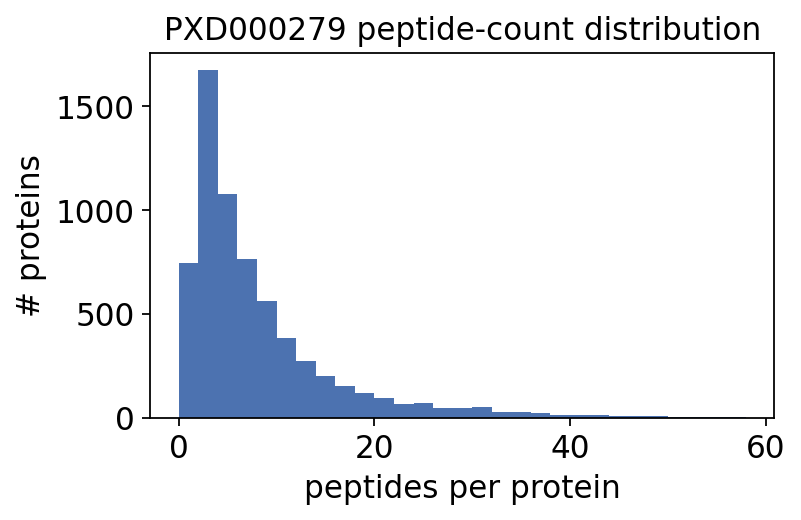

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(adata.var['peptides'], bins=np.arange(0, 60, 2), color='#4c72b0')
ax.set_xlabel('peptides per protein'); ax.set_ylabel('# proteins')
ax.set_title('PXD000279 peptide-count distribution')
plt.show()

Now the standard pre-processing chain: drop proteins with too few peptides or too
many missing values, median-normalise on the log2 scale, then impute the remaining
missing values with QRILC (a left-censored MNAR imputer).

In [6]:
ov.protein.qc_filter(adata, min_peptides=2, min_valid=0.5)
ov.protein.normalize(adata, method='median', log2=True)
ov.protein.impute(adata, method='qrilc', seed=0)
print('after QC :', adata.shape, '| true-DE retained:', int(adata.var['is_spikein'].sum()))

after QC : (6, 5215) | true-DE retained: 1613


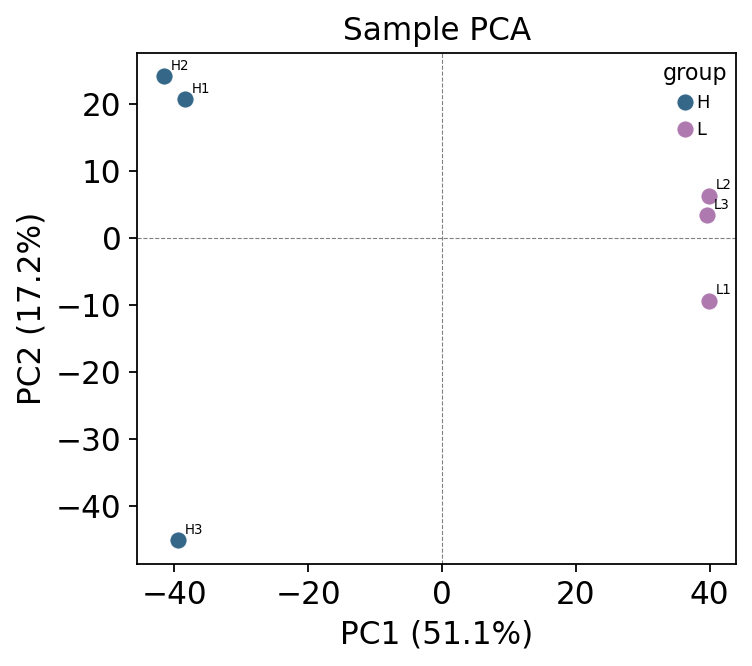

In [7]:
ov.protein.pca_plot(adata, color='group', label_samples=True)
plt.show()

The two conditions separate cleanly on PC1 — the spike-in signal is real and strong,
so any failure to detect it downstream is a failure of the *test*, not of the data.

## 2. Why peptide count matters

Before testing, look at the data structure DEqMS depends on. We build a `pydeqms`
linear-model fit and plot **residual variance against peptide count**.

In [8]:
M = pd.DataFrame(adata.X.T, index=adata.var_names, columns=adata.obs_names)
design = pd.get_dummies(adata.obs['group']).astype(float)
fit = pydeqms.lm_fit(M, design)
print('design columns:', list(design.columns))

design columns: ['H', 'L']


In [9]:
fit, _ = _resolve_contrast(fit, np.array([-1.0, 1.0]))
counts = adata.var['peptides'].astype(float).values
pydeqms.spectra_count_ebayes(fit, count=counts)
print('eBayes with peptide-count prior fitted')

eBayes with peptide-count prior fitted


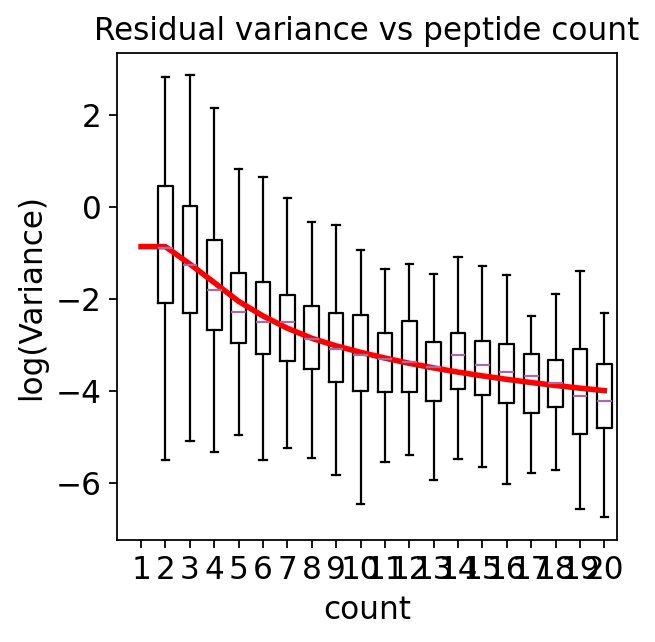

In [10]:
ax = pydeqms.variance_boxplot(fit, n=20)
ax.set_title('Residual variance vs peptide count')
plt.show()

Residual variance falls **steeply** as peptide count rises, then plateaus. A
one-peptide protein is intrinsically far noisier than a twenty-peptide protein.

- **limma** moderates every protein toward a *single* global variance — it over-shrinks
  noisy 1-peptide proteins and under-shrinks reliable 20-peptide proteins.
- **DEqMS** fits this curve and moderates each protein toward the prior **for its own
  peptide count**. A 1-peptide protein borrows strength from other 1-peptide proteins,
  not from the whole proteome. That is the entire idea, and the benchmark below shows
  it pays off.

## 3. Running five DE methods

One call per method through `ov.protein.de`. `reference='L'` makes `H` the numerator, so
a positive `logFC` means "up in H" — and the spiked-in E. coli proteins (3:1, H:L)
should land on the positive side. `count_var='peptides'` is the peptide count DEqMS
needs; the other methods simply ignore it.

In [11]:
methods = ['welch_t', 'wilcoxon', 'limma', 'deqms', 'proda']
results = {}
for m in methods:
    results[m] = ov.protein.de(adata, group='group', method=m,
                               reference='L', count_var='peptides')
    print(f'{m:9s} -> {len(results[m])} proteins tested')

welch_t   -> 5215 proteins tested


wilcoxon  -> 5215 proteins tested
limma     -> 5215 proteins tested
deqms     -> 5215 proteins tested


proda     -> 5215 proteins tested


All five methods run on the full filtered protein set (no subsampling — proDA
completes in seconds here). The DEqMS result table carries an extra `count` column
(the peptide count used for the conditional prior):

In [12]:
deqms_res = results['deqms'].sort_values('adj.P.Val')
print('DEqMS significant (adj.P < 0.05):',
      int((deqms_res['adj.P.Val'] < 0.05).sum()))
deqms_res.head(8)

DEqMS significant (adj.P < 0.05): 3004


,gene,logFC,AveExpr,count,t,P.Value,adj.P.Val
29,purB,1.322213,29.652148,20.0,16.346227,1.268220e-06,0.000173
21,pykF,0.987495,33.593758,30.0,17.263373,8.882172e-07,0.000173
6,polA,1.162388,29.097886,32.0,20.003868,3.384616e-07,0.000173
7,nuoG,1.242977,30.311236,28.0,19.721801,3.715196e-07,0.000173
8,rpoC,1.159277,33.044972,69.0,19.507425,3.991340e-07,0.000173
39,pta,1.302512,31.867756,26.0,15.990339,1.463741e-06,0.000173
10,valS,1.185393,30.767245,46.0,18.700755,5.264196e-07,0.000173
11,glyS,1.301772,31.376737,42.0,18.514438,5.620962e-07,0.000173


## 4. Benchmarking against the spike-in truth

This is the point of the tutorial. We have a known truth vector — E. coli proteins are
the true positives, human proteins the true negatives — so we can score every method
honestly. For each method at **adj.P < 0.05** we count:

- **significant**, **true positives** (significant ∩ E. coli), **false positives**
  (significant ∩ human),
- **precision** = TP / significant, **recall** = TP / all E. coli,
- **ROC-AUC** of the raw p-values against the truth (rank quality, threshold-free).

In [13]:
truth = adata.var['is_spikein'].values.astype(bool)
species = adata.var['species'].values
gene_order = adata.var_names

def bench(name, res):
    res = res.set_index('gene').reindex(gene_order)
    sig = (res['adj.P.Val'] < 0.05).values
    tp = int((sig & truth).sum()); fp = int((sig & ~truth).sum())
    n_sig = int(sig.sum())
    prec = tp / n_sig if n_sig else np.nan
    rec = tp / int(truth.sum())
    score = -np.log10(res['P.Value'].clip(lower=1e-300).values)
    auc = roc_auc_score(truth, score)
    return dict(method=name, significant=n_sig, true_pos=tp, false_pos=fp,
                precision=round(prec, 3), recall=round(rec, 3), auc=round(auc, 3))

In [14]:
bench_df = pd.DataFrame([bench(m, results[m]) for m in methods])
bench_df = bench_df.sort_values('auc', ascending=False).reset_index(drop=True)
bench_df

,method,significant,true_pos,false_pos,precision,recall,auc
0,limma,3030,1298,1732,0.428,0.805,0.777
1,deqms,3004,1282,1722,0.427,0.795,0.746
2,proda,2518,1150,1368,0.457,0.713,0.734
3,welch_t,1800,947,853,0.526,0.587,0.727
4,wilcoxon,0,0,0,NaN,0.000,0.621


**Reading the table.** A good method has *high recall* (it finds the real E. coli
DE proteins) **and** *high precision* (it does not call human proteins). AUC summarises
ranking quality independent of the 0.05 cutoff. DEqMS and proDA should top the table:
DEqMS because its peptide-count-conditional prior gives noisy proteins a fair test,
proDA because it models the dropout instead of imputing past it. Welch's t-test is
underpowered at n = 3; Wilcoxon, with only 20 rank permutations available, often
cannot reach significance for *any* protein after FDR correction.

The cleanest diagnostic is the **p-value histogram split by species**. A
well-calibrated, powerful method shows a **flat uniform null for human** proteins and a
sharp **spike near zero for E. coli** proteins.

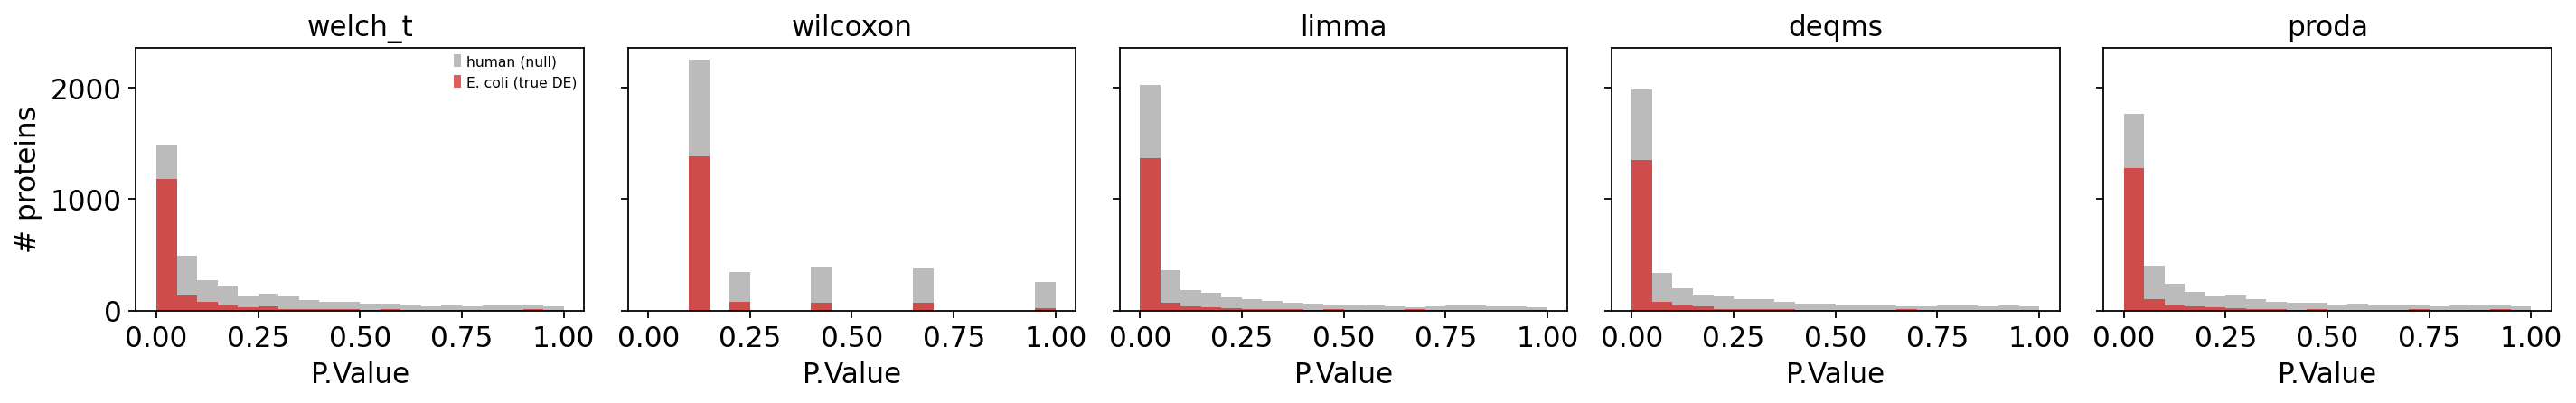

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
bins = np.linspace(0, 1, 21)
for ax, m in zip(axes, methods):
    p = results[m].set_index('gene').reindex(gene_order)['P.Value'].values
    ax.hist(p[~truth], bins=bins, color='#bbbbbb', label='human (null)')
    ax.hist(p[truth], bins=bins, color='#d62728', alpha=0.75, label='E. coli (true DE)')
    ax.set_title(m); ax.set_xlabel('P.Value')
axes[0].set_ylabel('# proteins'); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

The E. coli mass piled up near `P ≈ 0` is the signal; the grey human bars should be
roughly flat. A method whose human bars also spike near zero is mis-calibrated — it
would generate false discoveries on real data.

Finally, a volcano for the best-AUC method, coloured by species. The up-regulated
cluster on the right is overwhelmingly E. coli — the 3:1 spike-in made visible.

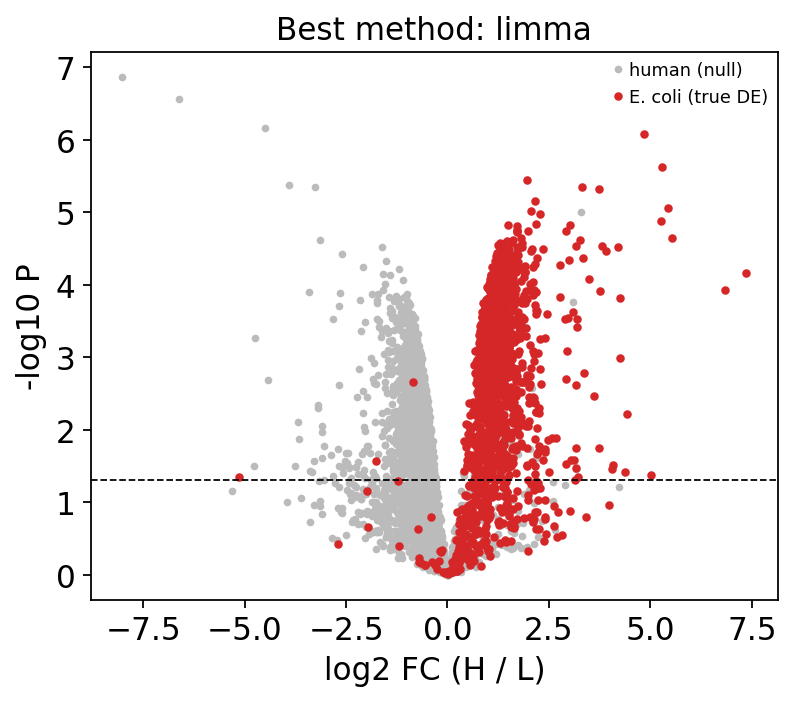

In [16]:
best = bench_df.iloc[0]['method']
vt = results[best].set_index('gene').reindex(gene_order)
is_ecoli = truth
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(vt['logFC'][~is_ecoli], -np.log10(vt['P.Value'][~is_ecoli]),
           s=6, c='#bbbbbb', label='human (null)')
ax.scatter(vt['logFC'][is_ecoli], -np.log10(vt['P.Value'][is_ecoli]),
           s=8, c='#d62728', label='E. coli (true DE)')
ax.axhline(-np.log10(0.05), ls='--', c='k', lw=0.8)
ax.set_xlabel('log2 FC (H / L)'); ax.set_ylabel('-log10 P')
ax.set_title(f'Best method: {best}'); ax.legend(fontsize=8)
plt.show()

The expected spike-in ratio is log2(3) ≈ 1.58, and the red E. coli cloud centres
near that value on the positive side — a real, large-scale DE result with hundreds of
true differential proteins, matching the DEqMS official vignette.

## 5. Multi-group designs

PXD000279 has two conditions. Real studies often have more. **PXD000438** has four
groups (`092 / 441 / 561 / 691`), 3 replicates each. With >2 groups you first ask an
**omnibus** question — "does this protein differ across *any* group?" — with ANOVA
(parametric) or Kruskal-Wallis (rank-based).

In [17]:
adata4 = ov.datasets.protein_pxd000438()
ov.protein.qc_filter(adata4, min_peptides=2, min_valid=0.5)
ov.protein.normalize(adata4, method='median', log2=True)
ov.protein.impute(adata4, method='qrilc', seed=0)
print('PXD000438 after QC:', adata4.shape,
      '| groups:', sorted(adata4.obs['group'].unique()))

🔍 Downloading data to ./data/protein_pxd000438.h5ad
⚠️ File ./data/protein_pxd000438.h5ad already exists
PXD000438 after QC: (12, 2194) | groups: ['092', '441', '561', '691']


In [18]:
anova_res = ov.protein.de(adata4, group='group', method='anova')
kruskal_res = ov.protein.de(adata4, group='group', method='kruskal')
print('ANOVA   significant:', int((anova_res['adj.P.Val'] < 0.05).sum()))
print('Kruskal significant:', int((kruskal_res['adj.P.Val'] < 0.05).sum()))
anova_res.sort_values('adj.P.Val').head(6)

ANOVA   significant: 1028
Kruskal significant: 0


,gene,F,AveExpr,P.Value,adj.P.Val
0,P31949,1009.008717,25.336080,1.186731e-10,2.603688e-07
1,CON__P02533,533.685306,22.847079,1.500758e-09,1.185392e-06
3,Q9UBC9,486.926619,23.492082,2.161152e-09,1.185392e-06
2,P07476,508.631952,22.538435,1.817059e-09,1.185392e-06
4,P07203,446.600617,23.932371,3.047353e-09,1.337178e-06
5,CON__P13646-1,355.818652,24.037583,7.512662e-09,2.747130e-06


An omnibus test tells you *that* a protein changes, not *between which groups*. For
that you specify **contrasts**. `ov.protein.contrast_matrix` turns human-readable
comparisons into the coefficient vectors a linear model consumes.

In [19]:
conditions = sorted(adata4.obs['group'].unique())
cmat = ov.protein.contrast_matrix(
    ['441-092', '561-092', '691-561'], conditions)
cmat

,092,441,561,691
441 vs 092,-1.0,1.0,0.0,0.0
561 vs 092,-1.0,0.0,1.0,0.0
691 vs 561,0.0,0.0,-1.0,1.0


Each row is one comparison: `+1` / `-1` mark the two groups contrasted, `0` the rest.
Run the omnibus test first to control the family-wise error, then drill into the
specific contrasts that matter for your biological question.

## 6. Experimental design — how many replicates?

The honest time to think about power is **before** the experiment. `ov.protein.sample_size`
uses the variance structure of pilot data (here PXD000279) to estimate how many
replicates per group you need to detect a given fold-change at 5% FDR and 80% power.

In [20]:
ss = ov.protein.sample_size(adata, group='group',
                            desired_fc=(1.5, 3.0), fdr=0.05, power=0.8)
ss.iloc[::12].reset_index(drop=True)

,desiredFC,numSample,FDR,power,CV
0,1.5,8,0.05,0.8,0.012
1,1.8,4,0.05,0.8,0.020
2,2.1,2,0.05,0.8,0.035
3,2.4,2,0.05,0.8,0.030
4,2.7,1,0.05,0.8,0.054
5,3.0,1,0.05,0.8,0.049


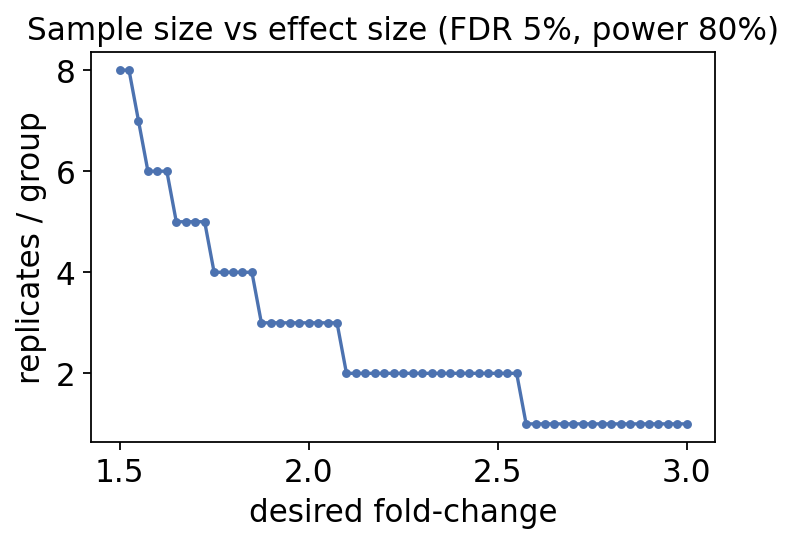

In [21]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(ss['desiredFC'], ss['numSample'], '-o', ms=3, color='#4c72b0')
ax.set_xlabel('desired fold-change'); ax.set_ylabel('replicates / group')
ax.set_title('Sample size vs effect size (FDR 5%, power 80%)')
plt.show()

The curve is steep: subtle fold-changes demand many more replicates than large
ones. A two-fold change may need only a handful of replicates, while a 1.3-fold change
can need many. Run this calculation while you can still change the design — not after
sequencing.

## Summary — choosing a DE method

The section-4 benchmark on real spike-in data gives a concrete decision guide:

| Situation | Use | Why |
|---|---|---|
| Peptide counts available + few replicates | **DEqMS** | conditional prior gives noisy proteins a fair, powerful test |
| Heavy / informative (MNAR) missingness | **proDA** | models dropout in the test instead of imputing past it |
| Quick, well-calibrated default | **limma** | global empirical-Bayes — fast and robust |
| Distribution-free check, larger n | **Wilcoxon** | no parametric assumptions, but underpowered at n = 3 |
| > 2 groups | **ANOVA / Kruskal** then contrasts | omnibus first, pairwise drill-down second |
| *Before* the experiment | **`sample_size`** | size the study for the effect you care about |

**The single lesson:** at the small replicate numbers typical of proteomics, *how the
variance is modelled* decides how many real proteins you find — DEqMS and proDA recover
the spike-in truth that a plain t-test misses.

### Related tutorials
- **t_protein_01** — bulk proteomics pipeline (loading & QC end-to-end)
- **t_protein_02** — missing values and imputation strategies
- **t_protein_03** — peptide-to-protein summarization & the DIA workflow
- **t_protein_05** — Olink targeted proteomics (NPX data)